In [2]:
import os
from IPython import extract_module_locals;
this_file = extract_module_locals()[1]["__vsc_ipynb_file__"]
current_folder = os.path.dirname(this_file)

import pandas as pd
import datetime
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from patsy import dmatrices

# Load the DataFrame and access its attributes
with pd.HDFStore(os.path.join(current_folder,'../DSD/mp_df_seed7.h5')) as store:
    mp_df = store.get('mp_df')

In [3]:
print(mp_df.columns)
mp_df[['learning_rate', 'batch_size', 'beta1', 'beta2', 'fused', 'foreach', 'patience', 'LocalOS', 'GPU', 'MISI', 'Epoch', 'MxE']]

Index(['experimenter', 'date_time', 'batch_size', 'learning_rate', 'weights',
       'seed', 'patience', 'beta1', 'beta2', 'fused', 'foreach', 'run_time',
       'epochs_completed', 'GPU', 'dataset_filename', 'running_data',
       'end_time', 'MISI', 'Epoch', 'MxE', 'MxE_log', 'MISI_log', 'Epoch_log',
       'LocalOS_bool', 'LocalOS', 'Foreach_Fused', 'Learning_rate_log',
       'Batch_size_log', 'Patience_log', 'beta1_0', 'beta2_0', 'run_time_log'],
      dtype='object')


,learning_rate,batch_size,beta1,beta2,fused,foreach,patience,LocalOS,GPU,MISI,Epoch,MxE
8,0.100,500,0.95,0.81,True,False,100,PC,A40,0.055110,100.0,5.511029
9,0.001,500,0.80,0.99,False,False,10,PC,A40,0.085334,800.0,68.266912
11,0.001,200,0.95,0.99,False,False,100,PC,A40,0.093301,800.0,74.641024
12,0.100,500,0.65,0.99,False,True,100,PC,RTX,0.082114,300.0,24.634308
13,0.010,316,0.80,0.90,False,True,32,PC,RTX,0.034882,300.0,10.464517
16,0.010,200,0.65,0.81,False,False,10,PC,RTX,0.026206,200.0,5.241201
17,0.001,200,0.95,0.81,True,False,32,PC,RTX,0.037335,800.0,29.868283
8,0.100,500,0.65,0.99,False,False,32,Mac,A40,0.078704,200.0,15.740770
9,0.010,500,0.95,0.99,True,False,100,Mac,A40,0.015834,500.0,7.916922
11,0.010,316,0.80,0.90,False,True,32,Mac,A40,0.026069,200.0,5.213869


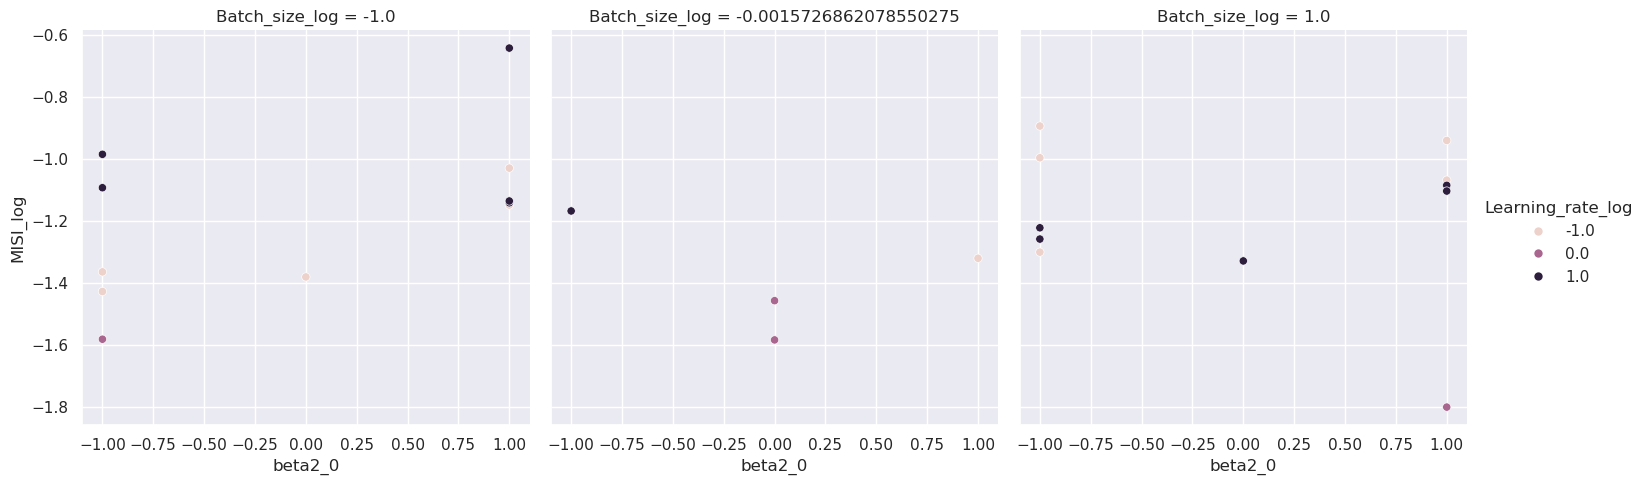

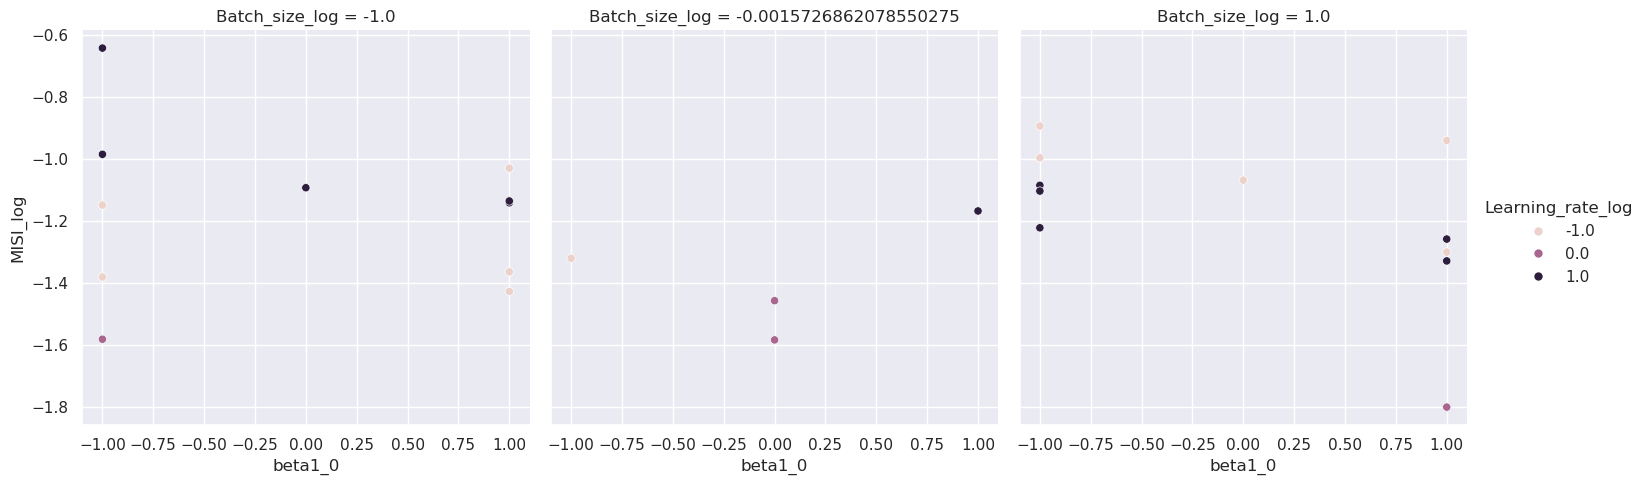

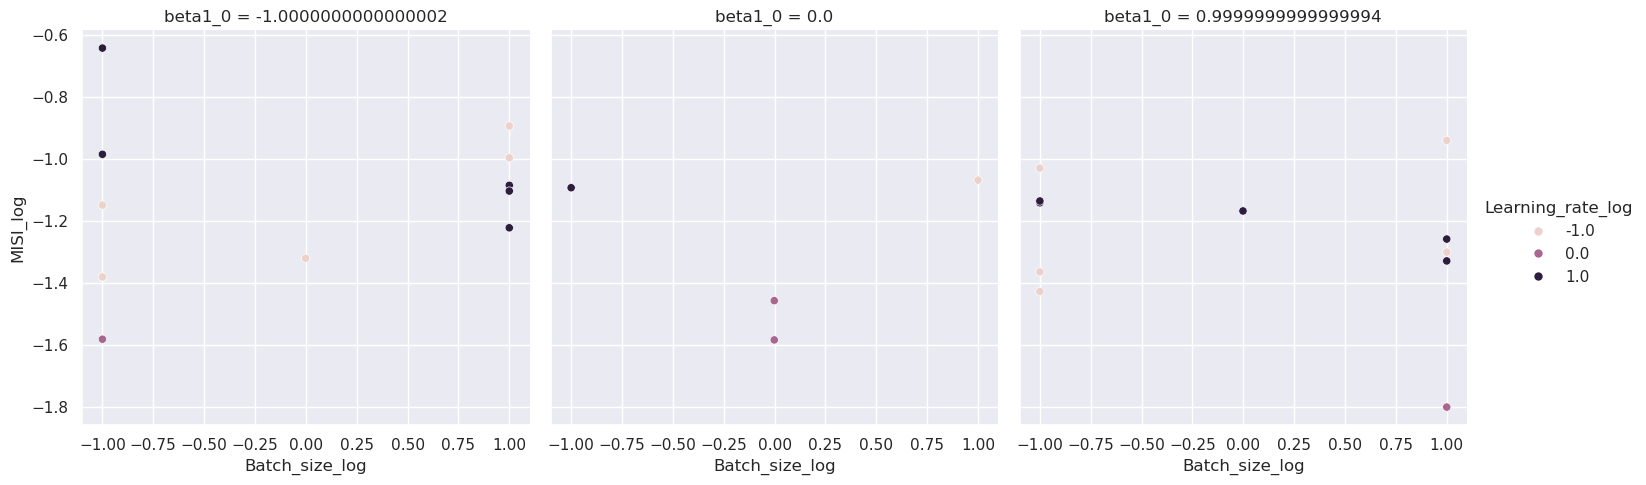

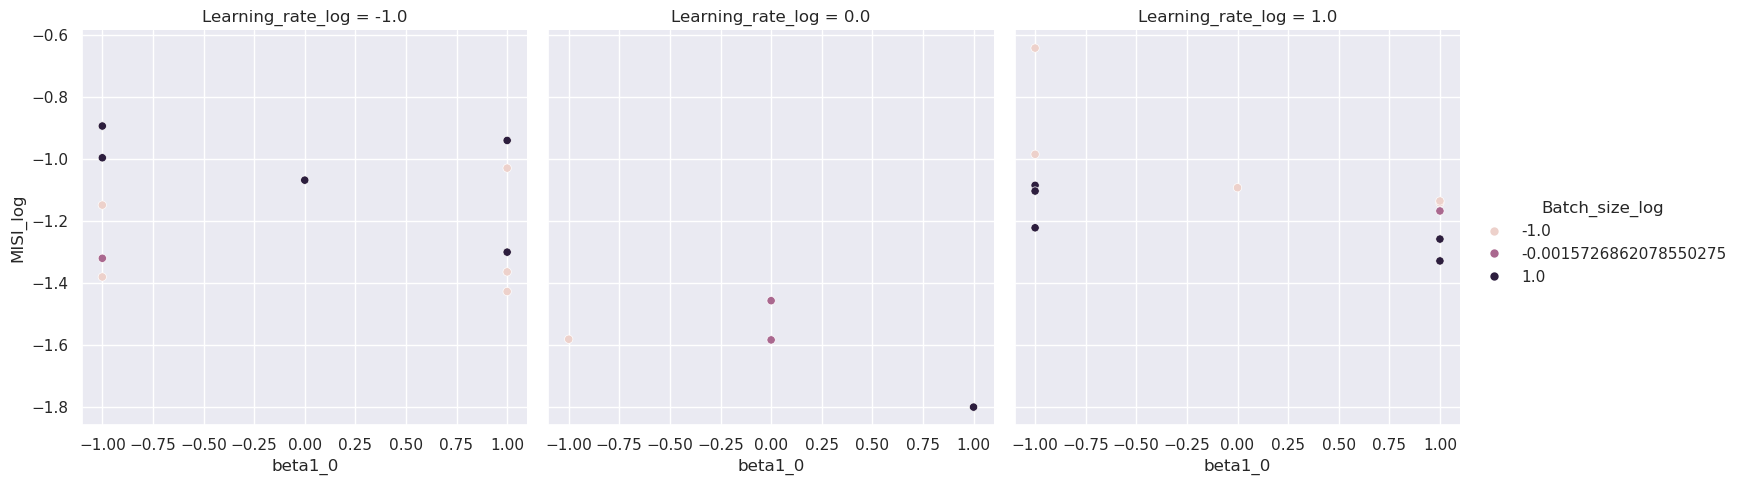

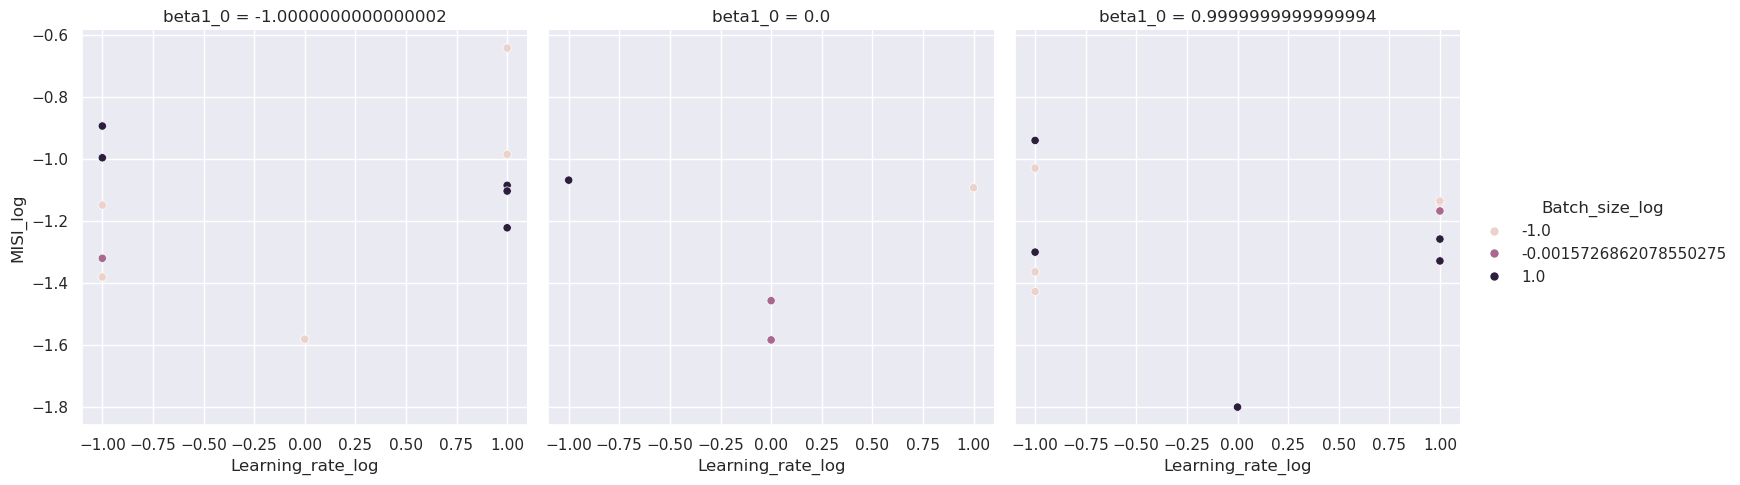

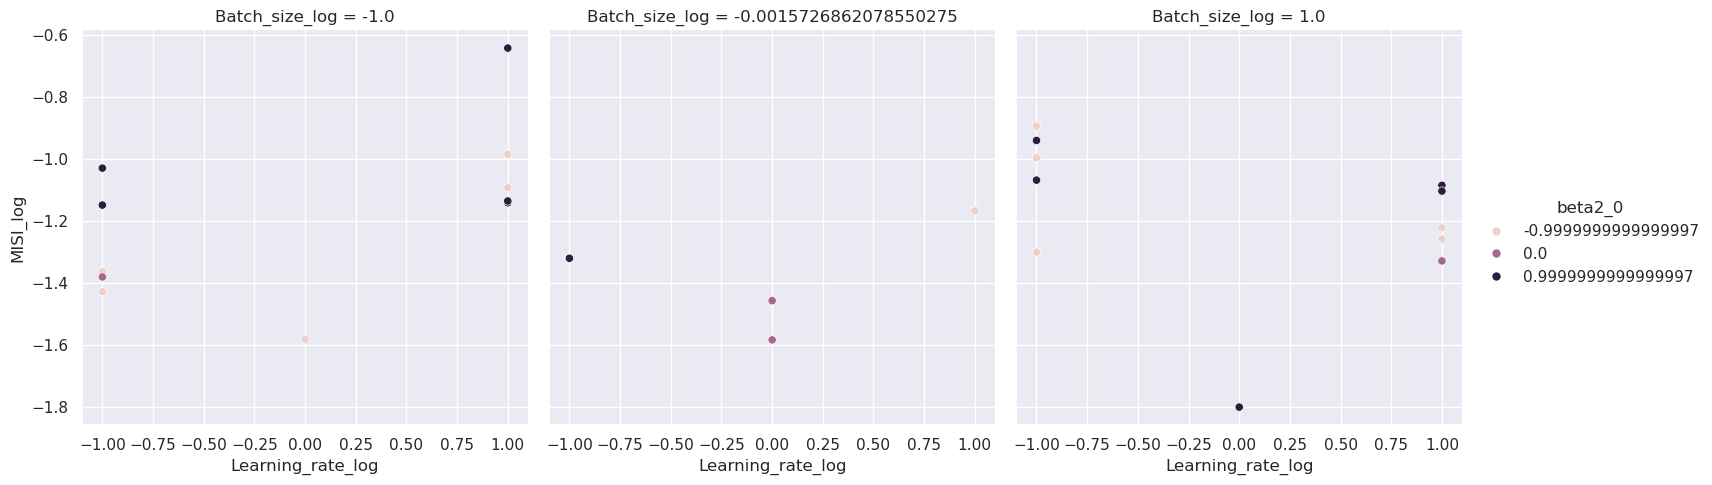

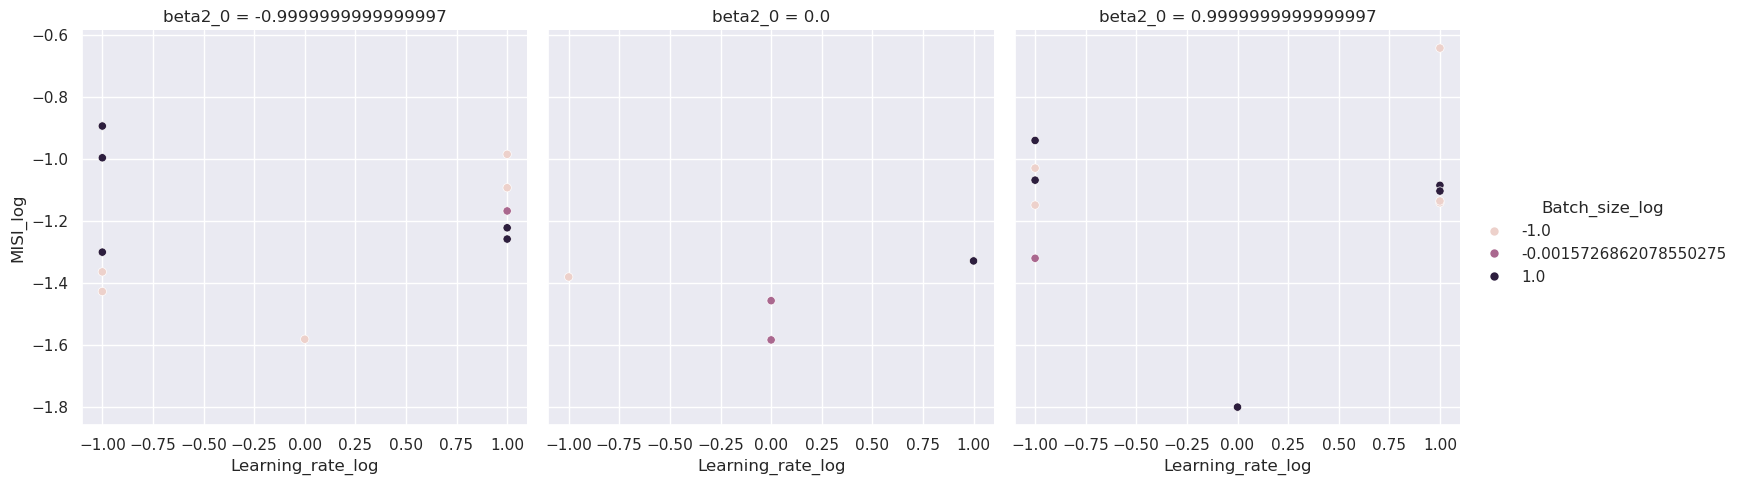

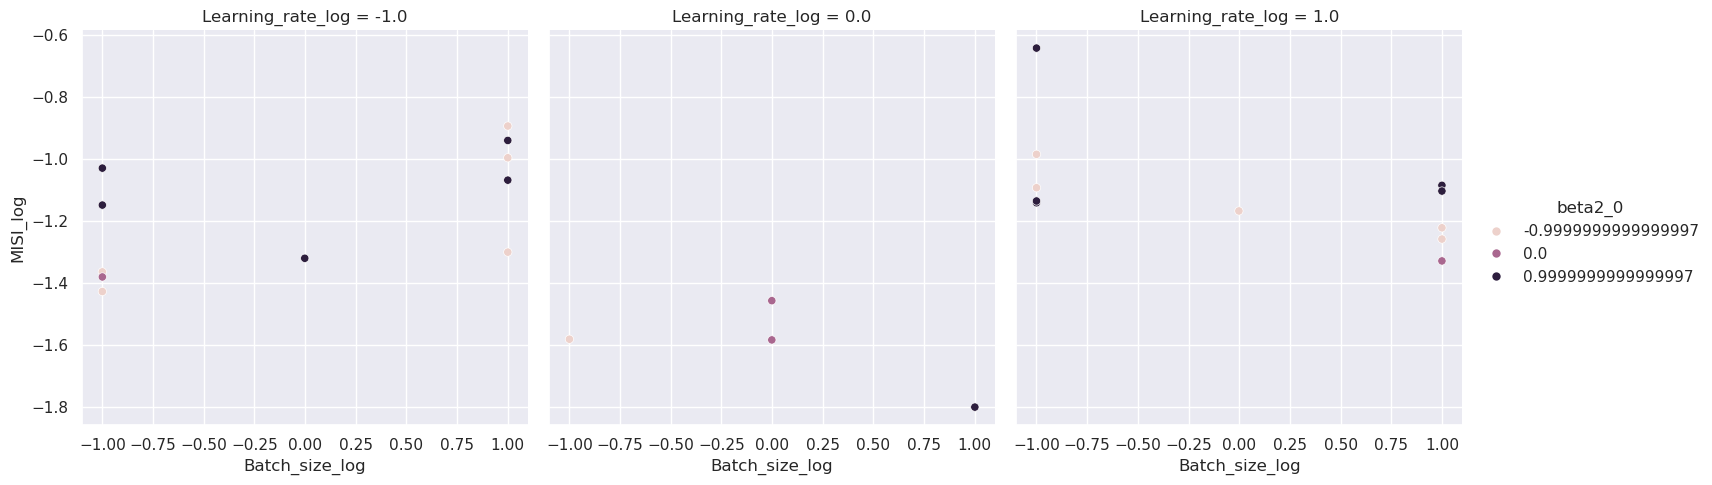

In [4]:
# Import seaborn
# import seaborn as sns

# Apply the default theme
sns.set_theme()

# # Create a visualization
# sns.relplot(
#     data=mp_df,
#     x="beta2_0", y="run_time", col="Batch_size_log", row="GPU",
#     hue="LocalOS"
# )

# Create a visualization
sns.relplot(
    data=mp_df,
    x="beta2_0", y="MISI_log", col="Batch_size_log",
    hue="Learning_rate_log"
)

sns.relplot(
    data=mp_df,
    x="beta1_0", y="MISI_log", col="Batch_size_log",
    hue="Learning_rate_log"
)

sns.relplot(
    data=mp_df,
    x="Batch_size_log", y="MISI_log", col="beta1_0",
    hue="Learning_rate_log"
)

sns.relplot(
    data=mp_df,
    x="beta1_0", y="MISI_log", col="Learning_rate_log",
    hue="Batch_size_log"
)

sns.relplot(
    data=mp_df,
    x="Learning_rate_log", y="MISI_log", col="beta1_0",
    hue="Batch_size_log"
)

sns.relplot(
    data=mp_df,
    x="Learning_rate_log", y="MISI_log", col="Batch_size_log",
    hue="beta2_0"
)

sns.relplot(
    data=mp_df,
    x="Learning_rate_log", y="MISI_log", col="beta2_0",
    hue="Batch_size_log"
)

sns.relplot(
    data=mp_df,
    x="Batch_size_log", y="MISI_log", col="Learning_rate_log",
    hue="beta2_0"
)

In [ ]:
# Quadratic function evaluation:

# Single vector input (x):
def f1v(x, A, b, c):
  return c + b.T @ x + x.T @ (A @ x)
# Multiple vector (matrix) input (x):
def f1m(x, A, b, c):
  return c + b.T @ x + np.sum(x * (A @ x), axis=0)

# Modified functions to impose bounds:
def f1v_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + x_clipped.T @ (A @ x_clipped)
def f1m_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + np.sum(x_clipped * (A @ x_clipped), axis=0)



def boundary_solver_1var_1eq(x0, U, boundary_values=[-1,1], exclude_vars=None):

    counter = 0
    x_stars = []
    x_ixs = [i for i in range(len(x0)) if i not in exclude_vars]
    for x_ix in x_ixs:
        for boundary_value in boundary_values:
            counter += 1
            print(counter)

            e = U[x_ix]
            f = boundary_value - x0[x_ix]
            k = f / e

            x_star = x0[:,None] + k * U # optimal value at boundary

            if np.any((x_star - max(boundary_values)) > 2) or np.any((x_star - min(boundary_values) < -2)):
                print('OUT OF BOUNDS')
            else:
                x_stars.append([x_star,f1v(x_star, A, b, c)])

            print('x_star:\n{val}'.format(val=x_star.T))
            print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
            print()

    return x_stars

def boundary_solver_2vars_2eqs(x0, U, boundary_values=[-1,1], exclude_vars=None):

    counter = 0
    x_stars = []
    x_ixs = []
    # for ix, U in enumerate([U_neg, U_zero]):
        # if U.shape[1] == 1:
        #     x_ixs.append([[i] for i in range(offset[ix],offset[ix]+len(x0)) if i not in exclude_vars])
    if U.shape[1] == 2:
        x_ixs = [[i,j] for i in range(len(x0)) if i not in exclude_vars
                        for j in range(len(x0)) if j not in exclude_vars and j > i]
    elif U.shape[1] == 3:
        x_ixs = [[i,j,k] for i in range(len(x0)) if i not in exclude_vars
                        for j in range(len(x0)) if j not in exclude_vars and j > i
                        for k in range(len(x0)) if k not in exclude_vars and k > j]
    # x_ix = [i for i in range(len(x0)) if i not in exclude_vars]
    # x_ixs = []
    # x_ixs.append([x_ix[kk] for kk in range(U.shape[1])])
    # for kk in range(U.shape[1]):
    #     if kk == 0:
    #         x_ixs = [[i] for i in range(len(x0)) if i not in exclude_vars]
    #     else:
    #         x_ixs = [xx.append(i) for xx in x_ixs if i > x_ixs[-1]]
    print(x_ixs)
    # U = np.concatenate([U_neg, U_zero], axis=1)
    print(U)
    boundary_tuples = []
    if U.shape[1] == 2:
        boundary_tuples = [[i,j] for i in boundary_values for j in boundary_values]
    elif U.shape[1] == 3:
        boundary_tuples = [[i,j,k] for i in boundary_values for j in boundary_values for k in boundary_values]

    for x_ix in x_ixs:
        # for x_ix_zero in x_ixs[1]:
        # x_ix = (x_ix_neg + x_ix_zero).sort()
        # print(x_ix_neg + x_ix_zero)
        for boundary_tuple in boundary_tuples:
            counter += 1
            print(counter)

            print(f"U:\n{U}")

            e = U[x_ix, :]
            f = np.array(boundary_tuple) - x0[x_ix]
            k = np.linalg.pinv(e) @ f[:,None]

            x_star = x0[:,None] + U @ k # optimal value at boundaries

            if np.any((x_star - max(boundary_values)) > 2) or np.any((x_star - min(boundary_values) < -2)):
                print('OUT OF BOUNDS')
            else:
                x_stars.append([x_star,f1v(x_star, A, b, c)])

            print('x_star:\n{val}'.format(val=x_star.T))
            print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
            print()

    return x_stars



def optimize_quadratic_with_bounds_old(A, b, c, bounds):

    print('c:\n{val}'.format(val=c))
    print('b:\n{val}'.format(val=b))
    print('A:\n{val}'.format(val=A))
    print()

    # stationary point: solution of grad_f(A,b,c)_wrt_x = 0 --> A @ x + b = 0 --> x0 = inv(A) @ (-b)
    x0 = np.linalg.pinv(A) @ (-b)
    print('x0:\n{val}'.format(val=x0))
    print("f1v at x0 (no bounds):", f1v(x0, A, b, c))
    print()

    # Retrieve eigenvectors and eigenvalues of A to determine curvatures of the quadratic function
    D, U = np.linalg.eigh(A)
    print('Eigenvalues (D):\n{val}'.format(val=D))
    print('Eigenvectors (U):\n{val}'.format(val=U))
    print()

    # # Find cols of A that are all zeros:
    # zero_cols = np.where(np.sum(np.abs(A), axis=0) == 0)[0]
    # print('excluding vars:\n{val}'.format(val=zero_cols+1))
    # print()

    semi_negative_curvatures = (D <= 0) # np.logical_and((D < 0), (np.abs(D) > 1e-3))
    if sum(semi_negative_curvatures) == 1:
        # Only 1 direction with negative curvature
        x_stars = boundary_solver_1var_1eq(x0, U[:,semi_negative_curvatures], boundary_values=bounds, exclude_vars=[])#zero_cols)
    elif sum(semi_negative_curvatures) == 0:
        # x0 is the minimum
        x_stars = [x0]
    else:
        # Multiple directions with negative curvature
        x_stars = boundary_solver_2vars_2eqs(x0, U[:,semi_negative_curvatures], boundary_values=bounds, exclude_vars=[])#zero_cols)


    return x_stars


In [406]:
# Quadratic function evaluation:

# Single vector input (x):
def f1v(x, A, b, c):
#   print(type(b), type(x))
  return c + b[None,:] @ x[:,None] + x[None,:] @ (A @ x[:,None])
# Multiple vector (matrix) input (x):
def f1m(x, A, b, c):
  return c + b[None,:] @ x + np.sum(x * (A @ x), axis=0)



# Modified functions to impose bounds:
def f1v_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + x_clipped.T @ (A @ x_clipped)
def f1m_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + np.sum(x_clipped * (A @ x_clipped), axis=0)


def generate_combinations(n, length, exclude_vars=[], start=0, prefix=None):
    # # Example usage:
    # x0 = [0, 1, 2, 3, 4]  # Example list
    # exclude_vars = [1]  # Example set of excluded indices
    # nested_loops = 3  # Number of nested loops

    # x_ixs = generate_combinations(nested_loops, len(x0), exclude_vars)
    # print(x_ixs)
    if prefix is None:
        prefix = []

    if n == 0:
        return [prefix]

    combinations = []
    for i in range(start, length):
        if i not in exclude_vars:
            combinations.extend(generate_combinations(n - 1, length, exclude_vars, i + 1, prefix + [i]))

    return combinations


def generate_boundary_tuples(dim, boundary_values, prefix=None):
    # # Example usage:
    # boundary_values = [0, 1]  # Example boundary values
    # dim = 3  # Equivalent to U.shape[1]

    # boundary_tuples = generate_boundary_tuples(dim, boundary_values)
    # print(boundary_tuples)

    if prefix is None:
        prefix = []

    if dim == 0:
        return [prefix]

    boundary_tuples = []
    for value in boundary_values:
        boundary_tuples.extend(generate_boundary_tuples(dim - 1, boundary_values, prefix + [value]))

    return boundary_tuples

import copy

def quadratic_boundary_solver(num_descend_dirs, A, b, c, boundary_values=[-1,1], exclude_vars=[]):
    x_ixs = generate_combinations(num_descend_dirs, A.shape[0], exclude_vars) # -1 is to not include the b term I injected in U
    # print(x_ixs)

    boundary_tuples = generate_boundary_tuples(num_descend_dirs, boundary_values) # -1 is to not include the b term I injected in U
    # print(boundary_tuples)

    x_stars = []
    counter = 0
    for x_ix in x_ixs:
        for boundary_tuple in boundary_tuples:
            counter += 1
            # print(counter)
            # print(f'A = {A}')
            # print(f'A[x_ix,:][:,x_ix] = {A[x_ix,:][:,x_ix]}')
            # print(f'b = {b}')

            x_star = np.zeros_like(b)

            x_star[x_ix] = np.array(boundary_tuple)

            not_x_ix = [i for i in range(A.shape[0]) if i not in x_ix and i not in exclude_vars]
            # print(f'A.shape = {A.shape}')
            # print(f'A[x_ix,:][:,not_x_ix] = {A[x_ix,:][:,not_x_ix]}')
            # print(f'b[not_x_ix] = {b[not_x_ix]}')

            # print(f'x_ix = {x_ix}')
            # print(f'not_x_ix = {not_x_ix}')
            # print(f'boundary_tuple = {boundary_tuple}')

            if not_x_ix:
                new_c = c + (np.array(boundary_tuple)[None,:] @ b[x_ix,None]) + (np.array(boundary_tuple)[None,:] @ A[x_ix,:][:,x_ix]) @ np.array(boundary_tuple)[:,None]

                new_b = b[not_x_ix] + 2 * (np.array(boundary_tuple)[None,:] @ A[x_ix,:][:,not_x_ix])[0]
                # print(f'b = {b}, new_b = {new_b}')

                new_A = A[not_x_ix,:][:,not_x_ix] # ensures new_A is 2D even if only 1 variable remains
                # print(f'new_A = {new_A}')
                # print(f'A[not_x_ix,:] = {A[not_x_ix,:]}')

                # zero_new_A = np.all(np.zeros_like(new_A)*0 == new_A)
                if np.all(np.diag(new_A) == new_A): # A_new is diagonal
                    D = np.diag(new_A)
                    # print(f'Eigenvalues of new_A (diagonal): {D}')
                else:
                    D = np.linalg.eigvalsh(new_A)
                    # print(f'Eigenvalues of new_A: {D}')
                
                # get machine precision for float type:
                eps = np.finfo(float).eps
                new_num_descend_dirs = sum(D <= np.sqrt(eps))
                # if sum(D <= np.sqrt(eps)) < num_descend_dirs:
                    # print('A_new is not positive definite, skipping this combination')
                    # continue

                # Recursive call to solver if new_A is all zeros or contains semi-negative curvatures:
                # May cause some combinations to be tried multiple times, but ensures all combinations are explored
                if new_num_descend_dirs > 0:
                    # print('new_A contains semi-negative curvatures, calling solver recursively')
                    # print(f'new_A = {new_A}')
                    new_x_stars = quadratic_boundary_solver(new_num_descend_dirs, new_A, new_b, new_c, boundary_values, exclude_vars)
                    # Find indexes of minimum values:
                    min_f1v = min([new_x_star[1][0][0] for new_x_star in new_x_stars])
                    new_x_stars = [new_x_star for new_x_star in new_x_stars if new_x_star[1][0][0] == min_f1v]
                    # print(f'new_x_stars: {new_x_stars}')
                    new_x_star = new_x_stars[0][0] # take the first one if multiple equivalent minima found
                else:
                    new_x_star = np.linalg.pinv(new_A, hermitian=True) @ (-new_b.T/2)
                    # print(f'new_x_star = {new_x_star}')

                x_star[not_x_ix] = np.squeeze(new_x_star)

            # This should be a while loop going over the largest deviation first, then refit, then check again, find the next largest violation and so on, until no vilations found and break:
            tt = 0
            x_ix_ = copy.deepcopy(x_ix)
            boundary_tuple_ = list(copy.deepcopy(boundary_tuple))
            while (x_star.max() - max(boundary_values)) > 0 or (x_star.min() - min(boundary_values)) < 0:
                tt += 1
                # print(f'  inner loop iteration: {tt}')
                # Apply constraint on largest absolute violation only: x_star in [-1, 1]
                new_x_ix = np.argmax(np.abs(x_star - np.clip(x_star, min(boundary_values), max(boundary_values))))
                # Add new_x_ix to x_ix_
                x_ix_.append(new_x_ix)
                x_ix_ = sorted(x_ix_)
                not_x_ix = [i for i in range(A.shape[0]) if i not in x_ix_ and i not in exclude_vars]
                # print(boundary_tuple_, type(boundary_tuple_))
                # put clipped x_star[new_x_ix] into boundary_tuple_ at the correct position, i.e., x_ix_ == new_x_ix index
                # print(f'location: {np.where(np.array(x_ix_) == new_x_ix)[0][0]}')
                boundary_tuple_.insert(np.where(np.array(x_ix_) == new_x_ix)[0][0],
                                      np.clip(x_star[new_x_ix], min(boundary_values), max(boundary_values)))
                # print(boundary_tuple_)

                # Refit new_x_star
                if not_x_ix:
                    new_c = c + (np.array(boundary_tuple_)[None,:] @ b[x_ix_,None]) + (np.array(boundary_tuple_)[None,:] @ A[x_ix_,:][:,x_ix_]) @ np.array(boundary_tuple_)[:,None]
                    new_b = b[not_x_ix] + 2 * (np.array(boundary_tuple_)[None,:] @ A[x_ix_,:][:,not_x_ix])
                    new_A = A[not_x_ix,:][:,not_x_ix] # ensures new_A is 2D even if only 1 variable remains
                    new_x_star = np.linalg.pinv(new_A, hermitian=True) @ (-new_b.T/2)
                    x_star = np.zeros_like(b)
                    x_star[x_ix_] = np.array(boundary_tuple_)
                    x_star[not_x_ix] = np.squeeze(new_x_star)
                else:
                    x_star = np.array(boundary_tuple_)
                    break

            x_stars.append([x_star,f1v(x_star, A, b, c)])

            # print(f'f1v({x_star}, A, b, c) = {f1v(x_star, A, b, c)}')

            # if counter == 23:
            #     print(f'f1v({x_star}, A, b, c) = {f1v(x_star, A, b, c)}')
            #     print(f'f1v({x_star[not_x_ix]}, new_A, new_b, new_c) = {f1v(x_star[not_x_ix], new_A, new_b, new_c)}')

            #     x_test_0 = -1
            #     x_test_1 = 1
            #     x_test = np.array([x_test_1, x_test_0, x_star[2], x_star[3]])
            #     print(f'f1v({x_test}, A, b, c) = {f1v(x_test, A, b, c)}')
            #     print(f'f1v({x_test[not_x_ix]}, new_A, new_b, new_c) = {f1v(x_test[not_x_ix], new_A, new_b, new_c)}')
                

            #     # plot f1v({x_test}, A, b, c) with x_test_0 going from -1 to 1 in 201 steps
            #     x_test_0s = np.linspace(-1, 1, 201)
            #     f1v_vals = [f1v(np.array([x_star[0], x0, x_star[2], x_star[3]]), A, b, c)[0][0] for x0 in x_test_0s]
            #     f1v_new_vals = [f1v(np.array([x0]), new_A, new_b, new_c)[0][0][0] for x0 in x_test_0s]

            #     f1v_vals0_1s = [f1v(np.array([x_test_1, x0, x_star[2], x_star[3]]), A, b, c)[0][0] for x0 in x_test_0s]
                
            #     print(f'b = {b}, new_b = {new_b}')
            #     print(f'new_A = {new_A}')

            #     print(np.linalg.pinv(new_A) @ (-new_b.T/2))

            #     plt.plot(x_test_0s, f1v_vals, label='Original')
            #     plt.plot(x_test_0s, f1v_new_vals, label='Reduced')
            #     plt.plot(x_test_0s, f1v_vals0_1s, label='Original (x_test_1=-1)')
            #     plt.axvline(x=x_test_0, color='r', linestyle='--', label='Brute Minimum')
            #     plt.axvline(x=x_star[1], color='g', linestyle='--', label='Stationary point')
            #     plt.title('Function values comparison')
            #     plt.xlabel('x_test_0')
            #     plt.ylabel('Function value')
            #     plt.legend()
            #     plt.grid()
            #     plt.show()

    return x_stars

def optimize_quadratic_with_bounds(A, b, c, bounds):

    print('c:\n{val}'.format(val=c))
    print('b:\n{val}'.format(val=b))
    print('A:\n{val}'.format(val=A))
    print()

    # stationary point: solution of grad_f(A,b,c)_wrt_x = 0 --> A @ x + b = 0 --> x0 = inv(A) @ (-b)
    x0 = np.linalg.pinv(A, hermitian=True) @ (-b/2)
    print('x0:\n{val}'.format(val=x0))
    # D_inv = D.copy()
    # D_inv[np.abs(D) > 1e-8] = 1/(D[np.abs(D) > 1e-8])
    # x0 = U @ (D_inv[:,None] * (U.T @ (-b[:,None])))
    # print('x0:\n{val}'.format(val=x0))
    print("f1v at x0 (no bounds):", f1v(x0, A, b, c))
    print()

    # Retrieve eigenvectors and eigenvalues of A to determine curvatures of the quadratic function
    D = np.linalg.eigvalsh(A)
    # D, U = np.linalg.eigh(A)
    print('Eigenvalues (D):\n{val}'.format(val=D))
    # print('Eigenvectors (U):\n{val}'.format(val=U))
    print()

    # # Find cols of A that are all zeros:
    # zero_cols = np.where(np.sum(np.abs(A), axis=0) == 0)[0]
    # print('excluding vars:\n{val}'.format(val=zero_cols+1))
    # print()

    semi_negative_curvatures = (D <= 1e-3) #
    # negative_curvatures = np.logical_and((D < 0), (np.abs(D) > 1e-3)) #
    # zero_curvatures = np.logical_and((D <= 0), (np.abs(D) <= 1e-3)) #
    # if sum(semi_negative_curvatures) == 1:
    #     # Only 1 direction with negative curvature
    #     x_stars = boundary_solver_1var_1eq(x0, U[:,semi_negative_curvatures], boundary_values=bounds, exclude_vars=[])#zero_cols)
    if sum(semi_negative_curvatures) == 0:
        # x0 is the minimum
        x_stars = [x0]
    else:
        # # Multiple directions with negative curvature
        # b_hat = (U[:,zero_curvatures] @ U[:,zero_curvatures].T) @ (b)
        # print('b_hat:\n{val}'.format(val=b_hat))
        # print()
        # print('b:\n{val}'.format(val=b))
        # print()
        # # e = (np.eye(U.shape[0]) - U[:,semi_negative_curvatures]@U[:,semi_negative_curvatures].T) @ b
        # # if np.sum(e**2)/np.sum(b**2) < 0.01:
        # #     x_stars = boundary_solver_2vars_2eqs(x0, U[:,semi_negative_curvatures], boundary_values=bounds, exclude_vars=[])#zero_cols)
        # # else:
        # Us = np.concatenate([U[:,negative_curvatures], -b_hat[:,None]], axis=1)
        # # x_stars = boundary_solver_2vars_2eqs(x0, Us, boundary_values=bounds, exclude_vars=[])#zero_cols)
        # # x_stars = quadratic_boundary_solver(Us.shape[1], A, b, c, boundary_values=[-1,1], exclude_vars=[])
        x_stars = quadratic_boundary_solver(sum(semi_negative_curvatures), A, b, c, boundary_values=[-1,1], exclude_vars=[])

    # x_stars = [[x_star,f1v(x_star, A, b, c)] for x_star in x_stars]

    # Find indexes of minimum values:
    min_f1v = min([x_star[1][0][0] for x_star in x_stars])
    x_stars = [x_star for x_star in x_stars if x_star[1][0][0] == min_f1v]

    # Remove repeated items in x_stars:
    x_stars = [x for i, x in enumerate(x_stars) if i == 0 or not np.array_equal(x[0], x_stars[i-1][0])]

    for x_star in x_stars:
        print('x_star:\n{val}'.format(val=x_star[0].T))
        print("f1v at x_star (no bounds):", f1v(x_star[0], A, b, c))
        print()

    return x_stars

In [200]:
# import numpy as np
# import matplotlib.pyplot as plt

def brute_force_quadratic_minimum(A, b, c):

    x = [np.arange(0,2.02,.02)-1 for dd in range(A.shape[0])]

    # X1, X2, X3, X4 = np.meshgrid(x[0], x[1], x[2], x[3])
    XD = [*np.meshgrid(*x)]
    X = np.concatenate([xx.reshape(-1,1) for xx in XD], axis=1)

    Y = c + X @ b + np.sum((X @ A) * X, axis=1)
    # Y = Y.reshape(X1.shape[0], X1.shape[1], X1.shape[2], X1.shape[3])
    Y = Y.reshape(*(XD[0].shape))

    # Minimum of the function ON THE GRID:
    min_idx = np.argmin(Y)
    min_idx = np.unravel_index(min_idx, Y.shape)

    return np.array([xx[min_idx] for xx in XD]), Y[min_idx]

def make_quadratic_contour_plots(A, b, c, lock, names, x_stars):

    keep = [kk for kk in range(A.shape[0]) if kk not in lock]

    x = [np.arange(0,2.01,.01)-1 if dd not in lock else np.round(x_stars[0][0][dd],2)*np.ones(1) for dd in range(A.shape[0])]
    GR_max = np.array([max([max(xx) for xx in x])])
    GR_min = np.array([min([min(xx) for xx in x])])

    # X1, X2, X3, X4 = np.meshgrid(x[0], x[1], x[2], x[3])
    XD = [*np.meshgrid(*x)]
    X = np.concatenate([xx.reshape(-1,1) for xx in XD], axis=1)

    Y = c + X @ b + np.sum((X @ A) * X, axis=1)
    # Y = Y.reshape(X1.shape[0], X1.shape[1], X1.shape[2], X1.shape[3])
    Y = Y.reshape(*(XD[0].shape))

    # Minimum of the function ON THE GRID:
    min_idx = np.argmin(Y)
    min_idx = np.unravel_index(min_idx, Y.shape)

    xsk2_vals = [np.round(x_stars[ss][0][keep[2]], decimals=2) for ss in range(len(x_stars))]
    x[keep[2]] = np.unique(np.concatenate(xsk2_vals + [GR_min, np.zeros(1), GR_max]))

    # enforce the  same colormap for all subplots:
    vmin = np.min(Y)
    vmax = np.max(Y)

    lock_slice = tuple(slice(None) if i not in lock else 0 for i in range(XD[0].ndim))
    lock_names = [f"{names[ll]} = 0" for ll in lock]
    fig, axs = plt.subplots(max(1,len(x[keep[2]])//5), min(len(x[keep[2]]),5), figsize=(15, max(1,len(x[keep[2]])//5)*5))
    for ix, val in enumerate(x[keep[2]]):
        ax = axs[ix]
        CS = ax.contour(XD[keep[0]][lock_slice][:,:,ix], XD[keep[1]][lock_slice][:,:,ix], Y[lock_slice][:,:,ix], vmin=vmin, vmax=vmax)
        ax.clabel(CS, inline=1, fontsize=10)
        ax.set_title(f"{names[keep[2]]} = {x[keep[2]][ix]}\n" + ', '.join(lock_names))
        ax.set_xlabel(names[keep[0]])
        if ix == 0:
            ax.set_ylabel(names[keep[1]])
        if round(XD[keep[2]][min_idx].item(),2) == val:
            ax.scatter(XD[keep[0]][min_idx], XD[keep[1]][min_idx], c='b', marker='o')
            if XD[keep[1]][min_idx] < 0:
                ax.annotate(f"{round(Y[min_idx].item(),2)}", (XD[keep[0]][min_idx], XD[keep[1]][min_idx]), textcoords="offset points", xytext=(0,10), ha='center')
            else:
                ax.annotate(f"{round(Y[min_idx].item(),2)}", (XD[keep[0]][min_idx], XD[keep[1]][min_idx]), textcoords="offset points", xytext=(0,-10), ha='center')
        for x_star in x_stars:
            if round(x_star[0][keep[2]].item(),2) == val:
                ax.scatter(x_star[0][keep[0]], x_star[0][keep[1]], c='r', marker='*')
                # Annotate the point with a value, making sure text does not spill outside of plot area:
                if x_star[0][keep[1]] < 0:
                    ax.annotate(f"{round(x_star[1].item(),2)}", (x_star[0][keep[0]], x_star[0][keep[1]]), textcoords="offset points", xytext=(0,10), ha='center')
                else:
                    ax.annotate(f"{round(x_star[1].item(),2)}", (x_star[0][keep[0]], x_star[0][keep[1]]), textcoords="offset points", xytext=(0,-20), ha='center')


    return XD, Y, axs

def make_quadratic_contour_plots2(A, b, c, lock, names, x_stars):

    keep = [kk for kk in range(A.shape[0]) if kk not in lock]

    x = [np.arange(0,2.01,.01)-1 if dd not in lock else np.round(x_stars[0][0][dd],2)*np.ones(1) for dd in range(A.shape[0])]
    # print(f'x_max = {[max(xx) for xx in x]}')
    GR_max = np.array([max([max(xx) for xx in x])])
    GR_min = np.array([min([min(xx) for xx in x])])

    # X1, X2, X3, X4 = np.meshgrid(x[0], x[1], x[2], x[3])
    XD = [*np.meshgrid(*x)]
    X = np.concatenate([xx.reshape(-1,1) for xx in XD], axis=1)

    Y = c + X @ b + np.sum((X @ A) * X, axis=1)
    # Y = Y.reshape(X1.shape[0], X1.shape[1], X1.shape[2], X1.shape[3])
    Y = Y.reshape(*(XD[0].shape))
    # print(f'Y shape = {Y.shape}')

    # Minimum of the function ON THE GRID:
    min_idx = np.argmin(Y)
    # print(f'min_idx = {min_idx}')
    min_idx = np.unravel_index(min_idx, Y.shape)
    # print(f'min_idx = {min_idx}')

    # xsk2_vals = [np.round(x_stars[ss][0][keep[2]], decimals=2) for ss in range(len(x_stars))]
    # x[keep[2]] = np.unique(np.concatenate(xsk2_vals + [GR_min, np.zeros(1), GR_max]))

    # enforce the  same colormap for all subplots:
    vmin = np.min(Y)
    vmax = np.max(Y)

    lock_slice = tuple(slice(None) if i not in lock else 0 for i in range(XD[0].ndim))
    # print(f'lock_slice = {lock_slice}')
    # print(f'Y[lock_slice] shape = {Y[lock_slice].shape}')
    lock_names = [f"{names[ll]} = {np.round(x_stars[0][0][ll],2)}" for ll in lock]
    fig, axs = plt.subplots(max(1,1//5), min(1,5), figsize=(1*5, max(1,1//5)*6.25))
    # print(f'lock = {lock}')
    # print(f'x len = {len(x)}')
    # print(f'x[lock[0]] shape = {x[lock[0]].shape}')
    for ix, val in enumerate(x[lock[0]]):
        # print(f'ix = {ix}, val = {val}')
        ax = axs
        CS = ax.contour(XD[keep[0]][lock_slice][:,:], XD[keep[1]][lock_slice][:,:], Y[lock_slice][:,:], vmin=vmin, vmax=vmax, levels=5, cmap='viridis')
        # print(f'Y[lock_slice][-1,:] = {Y[lock_slice][-1,:]}')
        ax.clabel(CS, inline=1, fontsize=24)
        ax.axis('square')
        ax.tick_params(axis='both', labelsize=18)
        ax.set_title('\n'.join(lock_names), fontsize=20)
        ax.set_xlabel(names[keep[0]], fontsize=24)
        if ix == 0:
            ax.set_ylabel(names[keep[1]], fontsize=24)
        if round(XD[lock[0]][min_idx].item(),2) == val:
            ax.scatter(XD[keep[0]][min_idx], XD[keep[1]][min_idx], c='r', marker='o')
            # print(f'Plotting minimum at {XD[keep[0]][min_idx]}, {XD[keep[1]][min_idx]} with value {Y[min_idx].item()}')
            if XD[keep[1]][min_idx] < 0:
                ax.annotate(f"{round(Y[min_idx].item(),2)}", (XD[keep[0]][min_idx], XD[keep[1]][min_idx]), textcoords="offset points", xytext=(0,16), ha='center', color='r', fontsize=24)
            else:
                ax.annotate(f"{round(Y[min_idx].item(),2)}", (XD[keep[0]][min_idx], XD[keep[1]][min_idx]), textcoords="offset points", xytext=(0,-16), ha='center', color='r', fontsize=24)


    return XD, Y, axs, fig

In [255]:
x_stars = {}

                            OLS Regression Results                            
Dep. Variable:               MISI_log   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     5.128
Date:                Tue, 14 Oct 2025   Prob (F-statistic):            0.00242
Time:                        23:24:02   Log-Likelihood:                 19.312
No. Observations:                  26   AIC:                            -16.62
Df Residuals:                      15   BIC:                            -2.785
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

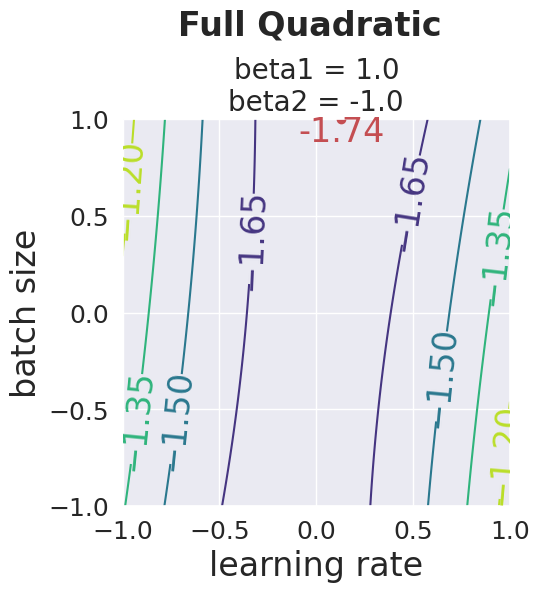

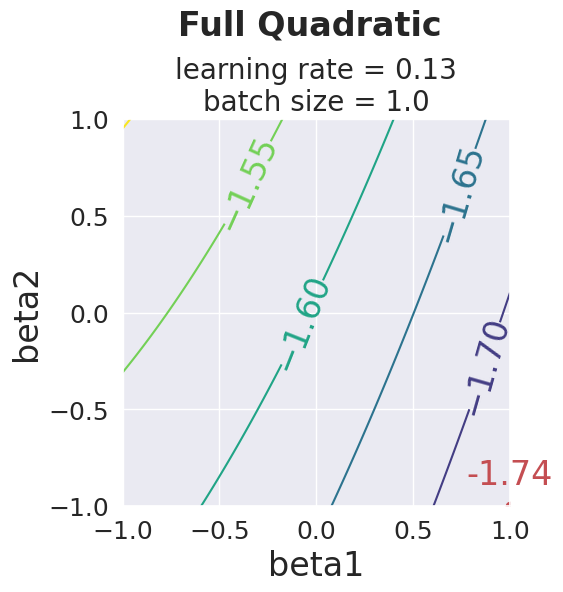

[0.02138053]


In [413]:
# MISI (all)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('MISI_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log:Batch_size_log + beta1_0:Learning_rate_log + Batch_size_log:beta1_0 + ' +
                         'I(Learning_rate_log**2) + I(beta1_0**2) + I(Batch_size_log**2)',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[lrm_mp.params['I(Learning_rate_log ** 2)'], (lrm_mp.params['Learning_rate_log:Batch_size_log']/2), (lrm_mp.params['beta1_0:Learning_rate_log']/2), 0],
              [(lrm_mp.params['Learning_rate_log:Batch_size_log']/2), lrm_mp.params['I(Batch_size_log ** 2)'], (lrm_mp.params['Batch_size_log:beta1_0']/2), 0],
              [(lrm_mp.params['beta1_0:Learning_rate_log']/2), (lrm_mp.params['Batch_size_log:beta1_0']/2), lrm_mp.params['I(beta1_0 ** 2)'], 0],
              [0, 0, 0, 0]])

x_stars['MISI_full'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])
print(x_stars)

# # names = ['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']
# # # lock = [3]
# # lock = []

# # XD, Y, axs = make_quadratic_contour_plots(A, b, c, lock, names, x_stars['MISI_full'])

# x_star, y_star = brute_force_quadratic_minimum(A, b, c)
# print(f"x_star:\n{x_star}")
# print(f"y_star_log:\n{y_star}")
# print(f"y_star:\n{10**y_star}")
# # x_stars['MISI_full'] = x_star

# # x_star, y_star = x_stars['MISI_full'][0][0], x_stars['MISI_full'][0][1]

# # plt.show()

print(f'MISI_full: {10**f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MISI_sig: {10**f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_full: {10**f1v(np.array([ 0.58,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_sig: {10**f1v(np.array([ 0.54,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'Epoch_full: {10**f1v(np.array([ 1.  , -1.  ,  0.46, -1.  ]),A,b,c)}')
print(f'Epoch_sig: {10**f1v(np.array([ 1., -1.,  1., -1.]),A,b,c)}')

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars['MISI_full']) # [[np.array([ 0.14,  1.  ,  1.  , -1.  ]),f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{MISI} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullMISI1.pdf', dpi=800, bbox_inches='tight') left
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2aleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars['MISI_full']) # [[np.array([ 0.14,  1.  ,  1.  , -1.  ]),f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{MISI} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullMISI2.pdf', dpi=800, bbox_inches='tight') right
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2aright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.0093, 300, 0.9233, 0.8700])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

                            OLS Regression Results                            
Dep. Variable:               MISI_log   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     9.292
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           8.00e-05
Time:                        23:23:37   Log-Likelihood:                 17.802
No. Observations:                  26   AIC:                            -21.60
Df Residuals:                      19   BIC:                            -12.80
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

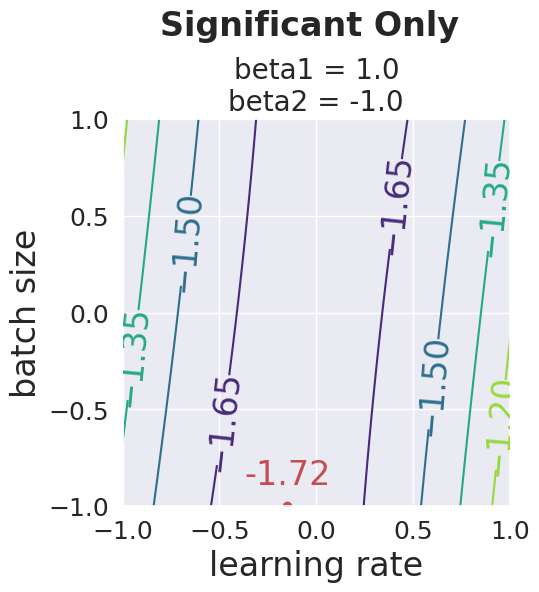

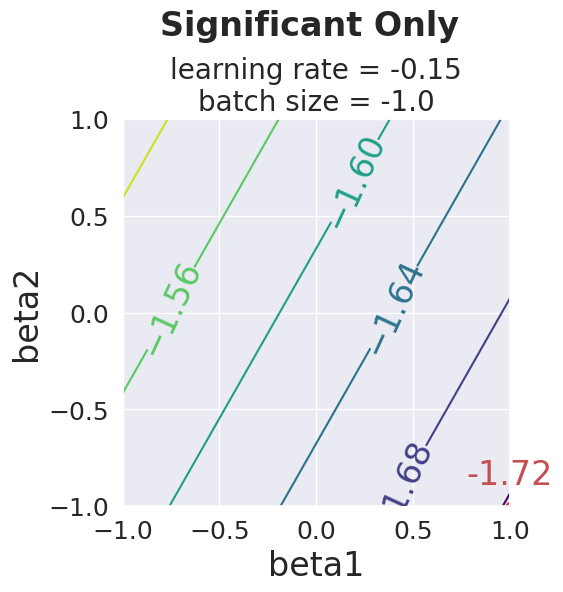

[0.02064028]


In [412]:
# MISI (only significant)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('MISI_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log:Batch_size_log + ' +
                         'I(Learning_rate_log**2)',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[lrm_mp.params['I(Learning_rate_log ** 2)'], (lrm_mp.params['Learning_rate_log:Batch_size_log']/2), 0, 0],
              [lrm_mp.params['Learning_rate_log:Batch_size_log']/2, 0 , 0 , 0],
              [0, 0, 0, 0],
              [0, 0, 0, 0]])

x_stars['MISI_sig'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])
print(x_stars)

# x_star, y_star = brute_force_quadratic_minimum(A, b, c)
# print(f"x_star:\n{x_star}")
# print(f"y_star_log:\n{y_star}")
# print(f"y_star:\n{10**y_star}")
# # x_stars['MISI_sig'] = x_star

# # x_stars['MISI_sig'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])

# # names = ['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']
# # lock = [3]

# # XD, Y, axs = make_quadratic_contour_plots(A, b, c, lock, names, x_stars['MISI_sig'])

# # plt.show()

print(f'MISI_full: {10**f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MISI_sig: {10**f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_full: {10**f1v(np.array([ 0.58,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_sig: {10**f1v(np.array([ 0.54,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'Epoch_full: {10**f1v(np.array([ 1.  , -1.  ,  0.46, -1.  ]),A,b,c)}')
print(f'Epoch_sig: {10**f1v(np.array([ 1., -1.,  1., -1.]),A,b,c)}')

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars['MISI_sig']) # [[np.array([-0.14, -1.  ,  1.  , -1.  ]),f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{MISI} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigMISI1.pdf', dpi=800, bbox_inches='tight')
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2dleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars['MISI_sig']) # [[np.array([-0.14, -1.  ,  1.  , -1.  ]),f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{MISI} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigMISI2.pdf', dpi=800, bbox_inches='tight')
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2dright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.0070, 200, 0.9500, 0.8700])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

                            OLS Regression Results                            
Dep. Variable:                MxE_log   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     9.462
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           8.08e-05
Time:                        23:23:18   Log-Likelihood:                 8.8627
No. Observations:                  26   AIC:                             4.275
Df Residuals:                      15   BIC:                             18.11
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

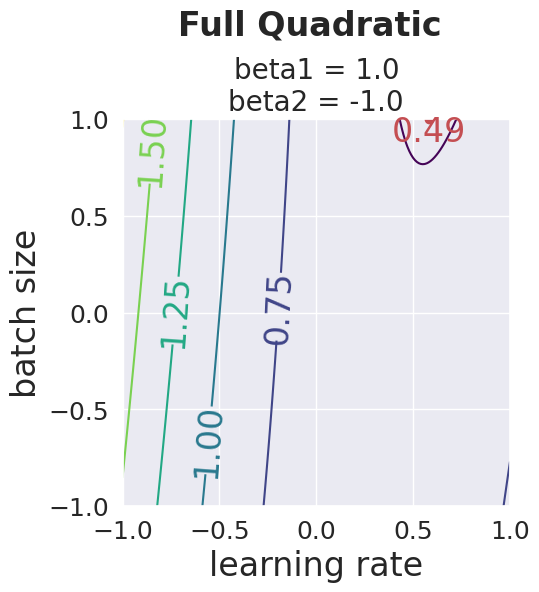

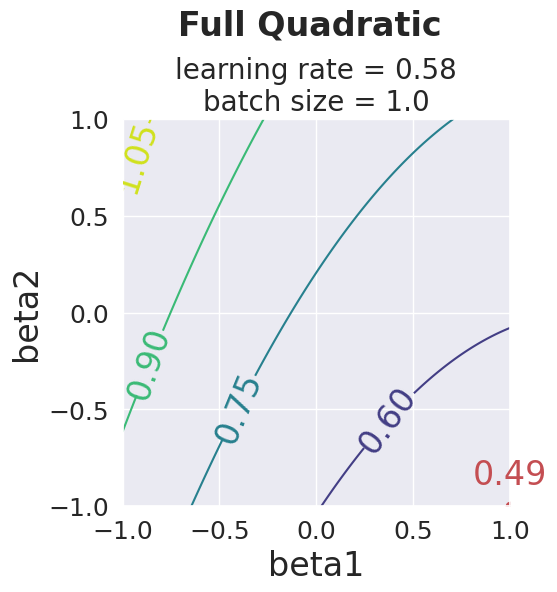

[3.81890772]


In [411]:
# 10/31 - MxE Full
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('MxE_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 +' +
                         'Learning_rate_log*Batch_size_log + Learning_rate_log*beta1_0 + Batch_size_log*beta1_0 + ' +
                         'I(Learning_rate_log**2) + I(beta1_0**2) + I(Batch_size_log**2) ',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[lrm_mp.params['I(Learning_rate_log ** 2)'], (lrm_mp.params['Learning_rate_log:Batch_size_log']/2), (lrm_mp.params['Learning_rate_log:beta1_0']/2), 0],
              [(lrm_mp.params['Learning_rate_log:Batch_size_log']/2), lrm_mp.params['I(Batch_size_log ** 2)'], (lrm_mp.params['Batch_size_log:beta1_0']/2), 0],
              [(lrm_mp.params['Learning_rate_log:beta1_0']/2), (lrm_mp.params['Batch_size_log:beta1_0']/2), lrm_mp.params['I(beta1_0 ** 2)'], 0],
              [0, 0, 0, 0]])

x_stars['MxE_full'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])
print(f'MxE_full x_stars: {x_stars["MxE_full"]}')

# x_star, y_star = brute_force_quadratic_minimum(A, b, c)
# print(f"x_star:\n{x_star}")
# print(f"y_star:\n{10**y_star}")
# print(y_star)
# # x_stars['MxE_full'] = x_star


# # x_stars['MxE_full'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])

# x_plot = np.array([ 0.58,  1.  ,  1.  , -1.  ])

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars["MxE_full"]) # [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{M \times E} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullMxE1.pdf', dpi=800, bbox_inches='tight')
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2bleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars["MxE_full"]) # [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{M \times E} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullMxE2.pdf', dpi=800, bbox_inches='tight')
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2bright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.0290, 300, 0.95,0.8484])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

                            OLS Regression Results                            
Dep. Variable:                MxE_log   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     15.95
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           1.56e-06
Time:                        23:23:02   Log-Likelihood:                 8.6728
No. Observations:                  26   AIC:                            -1.346
Df Residuals:                      18   BIC:                             8.719
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

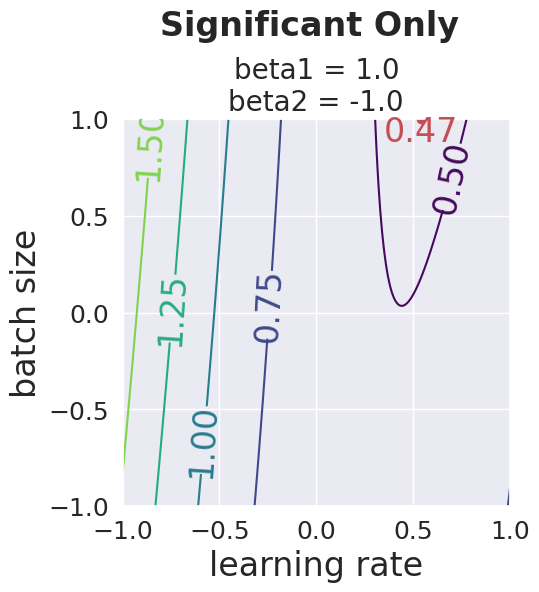

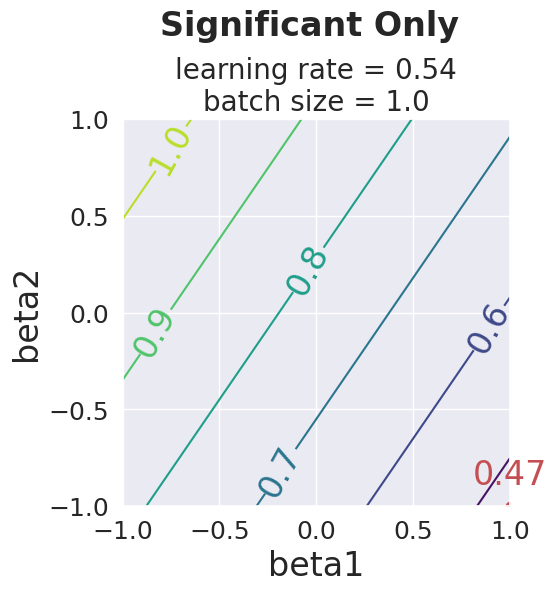

[3.17333565]


In [410]:
# 10/31 - MxE (Sig. only))
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('MxE_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 +' +
                         'Learning_rate_log*Batch_size_log + Learning_rate_log*beta1_0 + ' +
                         'I(Learning_rate_log**2)',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[lrm_mp.params['I(Learning_rate_log ** 2)'], (lrm_mp.params['Learning_rate_log:Batch_size_log']/2), (lrm_mp.params['Learning_rate_log:beta1_0']/2), 0],
              [(lrm_mp.params['Learning_rate_log:Batch_size_log']/2), 0, 0, 0],
              [(lrm_mp.params['Learning_rate_log:beta1_0']/2), 0, 0, 0],
              [0, 0, 0, 0]])

x_stars['MxE_sig'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])
print(f'MxE_sig x_stars: {x_stars["MxE_sig"]}')

# x_star, y_star = brute_force_quadratic_minimum(A, b, c)
# print(f"x_star:\n{x_star}")
# print(f"y_star_log:\n{y_star}")
# print(f"y_star:\n{10**y_star}")
# # x_stars['MxE_sig'] = x_star

# # x_stars['MxE_sig'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])

# x_plot = np.array([ 0.54,  1.  ,  1.  , -1.  ])

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars['MxE_sig']) # [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{M \times E} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigMxE1.pdf', dpi=800, bbox_inches='tight')
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2eleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars['MxE_sig']) # [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{M \times E} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigMxE2.pdf', dpi=800, bbox_inches='tight')
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2eright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.0265, 300, 0.9500, 0.8100])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

                            OLS Regression Results                            
Dep. Variable:              Epoch_log   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     31.39
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           3.02e-08
Time:                        23:22:46   Log-Likelihood:                 27.724
No. Observations:                  26   AIC:                            -33.45
Df Residuals:                      15   BIC:                            -19.61
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

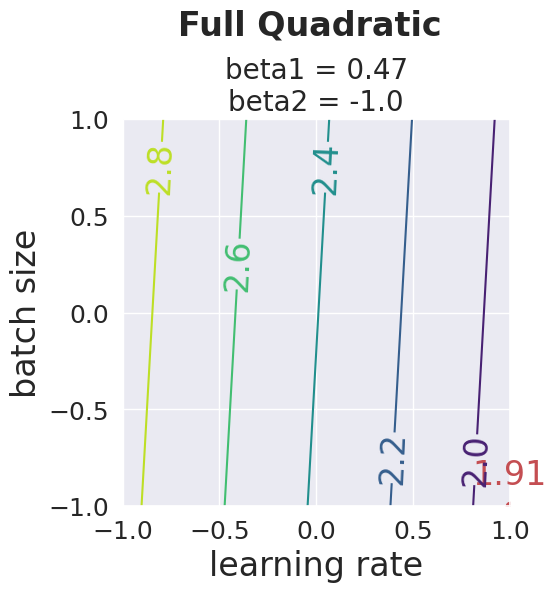

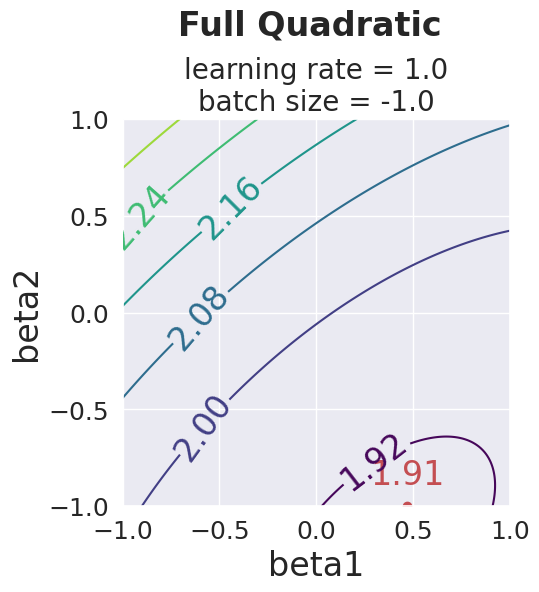

[85.8580103]


In [409]:
# Epoch (full model)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('Epoch_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log:beta1_0 + Learning_rate_log:beta2_0 + ' +
                         'beta1_0:beta2_0 + ' +
                         'I(Learning_rate_log**2) + I(beta1_0**2) + I(beta2_0**2)',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[lrm_mp.params['I(Learning_rate_log ** 2)'], 0, (lrm_mp.params['Learning_rate_log:beta1_0']/2), (lrm_mp.params['Learning_rate_log:beta2_0']/2)],
              [0, 0, 0, 0],
              [(lrm_mp.params['Learning_rate_log:beta1_0']/2), 0, lrm_mp.params['I(beta1_0 ** 2)'], (lrm_mp.params['beta1_0:beta2_0']/2)],
              [(lrm_mp.params['Learning_rate_log:beta2_0']/2), 0, (lrm_mp.params['beta1_0:beta2_0']/2), lrm_mp.params['I(beta2_0 ** 2)']]])

x_stars['Epoch_full'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])
print(f'Epoch_full x_stars: {x_stars["Epoch_full"]}')

# x_star, y_star = brute_force_quadratic_minimum(A, b, c)
# print(f"x_star:\n{x_star}")
# print(f"y_star_log:\n{y_star}")
# print(f"y_star:\n{10**y_star}")
# # x_stars['Epoch_full'] = x_star

# # x_stars['Epoch_full'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])

# '''{'MISI_full': array([ 0.14,  1.  ,  1.  , -1.  ]),
#  'MISI_sig': array([-0.14, -1.  ,  1.  , -1.  ]),
#  'MxE_full': array([ 0.58,  1.  ,  1.  , -1.  ]),
#  'MxE_sig': array([ 0.54,  1.  ,  1.  , -1.  ]),
#  'Epoch_full': array([ 1.  , -1.  ,  0.46, -1.  ]),
#  'Epoch_sig': array([ 1., -1.,  1., -1.])}
#  '''

print(f'MISI_full: {10**f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MISI_sig: {10**f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_full: {10**f1v(np.array([ 0.58,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_sig: {10**f1v(np.array([ 0.54,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'Epoch_full: {10**f1v(np.array([ 1.  , -1.  ,  0.46, -1.  ]),A,b,c)}')
print(f'Epoch_sig: {10**f1v(np.array([ 1., -1.,  1., -1.]),A,b,c)}')

# x_plot = np.array([ 1.  , -1.  ,  0.46, -1.  ])

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars['Epoch_full']) # [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{Epochs} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullEpoch1.pdf', dpi=800, bbox_inches='tight')
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2cleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars['Epoch_full']) # [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{Epochs} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullEpoch2.pdf', dpi=800, bbox_inches='tight')
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2cright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.1000, 200, 0.8990, 0.8154])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

                            OLS Regression Results                            
Dep. Variable:              Epoch_log   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     48.05
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           2.27e-10
Time:                        23:22:27   Log-Likelihood:                 26.322
No. Observations:                  26   AIC:                            -36.64
Df Residuals:                      18   BIC:                            -26.58
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

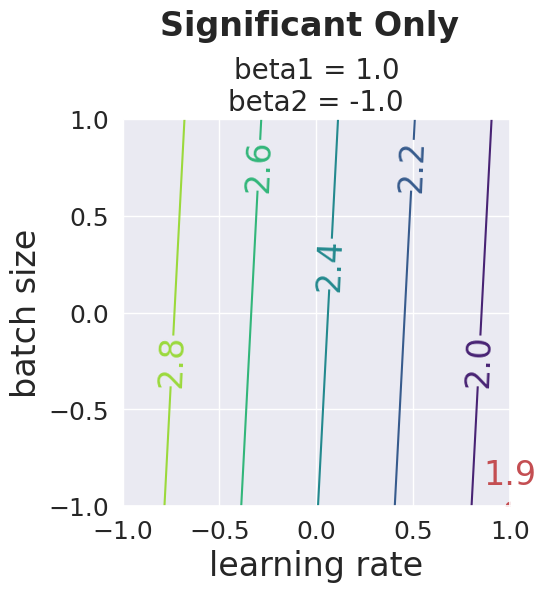

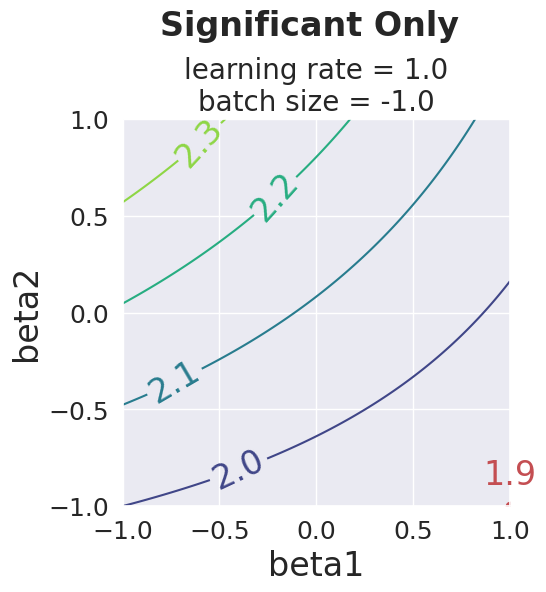

[85.32810029]


In [407]:
# Epoch (sig. only)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('Epoch_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log:beta1_0 + Learning_rate_log:beta2_0 + ' +
                         'beta1_0:beta2_0',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[0, 0, (lrm_mp.params['Learning_rate_log:beta1_0']/2), (lrm_mp.params['Learning_rate_log:beta2_0']/2)],
              [0, 0, 0, 0],
              [(lrm_mp.params['Learning_rate_log:beta1_0']/2), 0, 0, (lrm_mp.params['beta1_0:beta2_0']/2)],
              [(lrm_mp.params['Learning_rate_log:beta2_0']/2), 0, (lrm_mp.params['beta1_0:beta2_0']/2), 0]])

x_stars['Epoch_sig'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])
print(f'Epoch_sig x_stars: {x_stars["Epoch_sig"]}')

# x_star, y_star = brute_force_quadratic_minimum(A, b, c)
# print(f"x_star:\n{x_star}")
# print(f"y_star_log:\n{y_star}")
# print(f"y_star:\n{10**y_star}")
# # x_stars['Epoch_sig'] = x_star

# # x_stars['Epoch_sig'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])

# print(f'MISI_full: {10**f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)}')
# print(f'MISI_sig: {10**f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)}')
# print(f'MxE_full: {10**f1v(np.array([ 0.58,  1.  ,  1.  , -1.  ]),A,b,c)}')
# print(f'MxE_sig: {10**f1v(np.array([ 0.54,  1.  ,  1.  , -1.  ]),A,b,c)}')
# print(f'Epoch_full: {10**f1v(np.array([ 1.  , -1.  ,  0.46, -1.  ]),A,b,c)}')
# print(f'Epoch_sig: {10**f1v(np.array([ 1., -1.,  1., -1.]),A,b,c)}')

# x_plot = np.array([ 1., -1.,  1., -1.])

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars['Epoch_sig']) # [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{Epochs} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigEpoch1.pdf', dpi=800, bbox_inches='tight')
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2fleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, x_stars['Epoch_sig']) # [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{Epochs} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigEpoch2.pdf', dpi=800, bbox_inches='tight')
# fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2fright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.1000, 200, 0.9190, 0.8100])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)